# LambdaLLG 1D Bloch Domain Wall Test

This notebook tests the new 1D bulk DMI term in two steps:

1. Relax a Neel-like wall with and without bulk DMI and check whether the wall core rotates into a Bloch texture.
2. Start from a DMI-stabilized Bloch wall and drive it with a small easy-axis field.

For a 1D chain with bulk DMI vector parallel to the chain, the standard expectation is that the DMI selects a chiral Bloch wall. In contrast, interfacial DMI would favor a Neel wall.


In [1]:
using Pkg; Pkg.activate("../")


  Activating project at `C:\Users\freye\PersonalCode\LambdaLLG.jl`


In [2]:
using LambdaLLG
using LinearAlgebra
using Statistics
import PyPlot as plt


## Helpers

The wall coordinate is extracted from the site where `m_z` is closest to zero.


In [3]:
function normalize_column!(v)
    n = sqrt(sum(abs2, v))
    v ./= n
    return v
end

function neel_wall(Nx, x0, Delta)
    s0 = zeros(3, Nx)
    for i in 1:Nx
        xi = (i - x0) / Delta
        mz = tanh(xi)
        mx = 1 / cosh(xi)
        s0[:, i] .= (mx, 0.0, mz)
        normalize_column!(view(s0, :, i))
    end
    return s0
end

function bloch_wall(Nx, x0, Delta; chirality=1.0)
    s0 = zeros(3, Nx)
    for i in 1:Nx
        xi = (i - x0) / Delta
        mz = tanh(xi)
        my = chirality / cosh(xi)
        s0[:, i] .= (0.0, my, mz)
        normalize_column!(view(s0, :, i))
    end
    return s0
end

wall_center(mz) = argmin(abs.(mz))

function wall_centers(sol, Nx)
    return [wall_center(reshape(u, 3, Nx)[3, :]) for u in sol.u]
end

function wall_summary(spins)
    c = wall_center(spins[3, :])
    return (
        center = c,
        center_spin = spins[:, c],
        mean_abs_mx = mean(abs.(spins[1, :])),
        mean_abs_my = mean(abs.(spins[2, :])),
    )
end


wall_summary (generic function with 1 method)

## Model Parameters

These values were chosen to give a clear qualitative demonstration. You can edit them and rerun the notebook.


In [29]:
Nx = 121
x0 = (Nx + 1) / 2
Delta = 6.0

J = 1.0
K = (0.0, 0.0, 0.35)
alpha = 0.25

D_bulk = (0.3, 0.0, 0.0)
B_drive = (0.0, 0.0, 0.02)

t_relax = (0.0, 120.0)
t_drive = (0.0, 80.0)


(0.0, 80.0)

## 1. Does bulk DMI select a Bloch wall?

We start from a Neel-like wall and relax three cases: no DMI, positive bulk DMI, and negative bulk DMI.
If the bulk DMI term is behaving correctly, the wall core should develop a strong `m_y` component and the sign of that core `m_y` should flip when `D_bulk` changes sign. Note the curling at the edges is to be expected when including DMI in atomistic codes


In [30]:
s_neel0 = neel_wall(Nx, x0, Delta)

p_no_dmi = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=(0.0, 0.0, 0.0))
p_plus_dmi = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=D_bulk)
p_minus_dmi = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=(-D_bulk[1], -D_bulk[2], -D_bulk[3]))

sol_no_dmi = evolve1D(copy(s_neel0), t_relax, p_no_dmi; reltol=1e-6, abstol=1e-6)
sol_plus_dmi = evolve1D(copy(s_neel0), t_relax, p_plus_dmi; reltol=1e-6, abstol=1e-6)
sol_minus_dmi = evolve1D(copy(s_neel0), t_relax, p_minus_dmi; reltol=1e-6, abstol=1e-6)

s_no_dmi = reshape(sol_no_dmi.u[1], 3, Nx)
s_plus_dmi = reshape(sol_plus_dmi.u[end], 3, Nx)
s_minus_dmi = reshape(sol_minus_dmi.u[end], 3, Nx)

summary_no_dmi = wall_summary(s_no_dmi)
summary_plus_dmi = wall_summary(s_plus_dmi)
summary_minus_dmi = wall_summary(s_minus_dmi)

display(summary_no_dmi)
display(summary_plus_dmi)
display(summary_minus_dmi)


(center = 61, center_spin = [1.0, 0.0, 0.0], mean_abs_mx = 0.1557731785291997, mean_abs_my = 0.0)

(center = 72, center_spin = [0.0012250061453374457, 0.9777290860360867, -0.20986741928889935], mean_abs_mx = 6.620458972947746e-5, mean_abs_my = 0.05899565306062489)

(center = 50, center_spin = [0.0012250061453374457, -0.9777290860360867, 0.20986741928889935], mean_abs_mx = 6.620458972947743e-5, mean_abs_my = 0.05899565306062488)

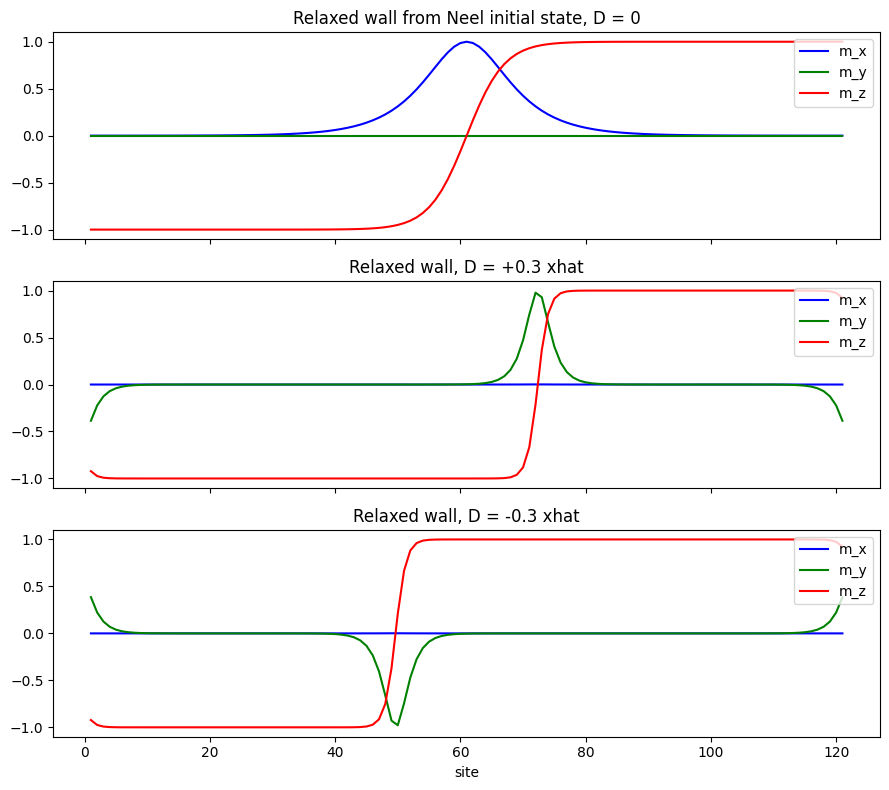

In [32]:
sites = 1:Nx

fig, ax = plt.subplots(3, 1, figsize=(9, 8), sharex=true)

ax[1].plot(sites, s_no_dmi[1, :], "b", label="m_x")
ax[1].plot(sites, s_no_dmi[2, :], "g", label="m_y")
ax[1].plot(sites, s_no_dmi[3, :], "r", label="m_z")
ax[1].set_title("Relaxed wall from Neel initial state, D = 0")
ax[1].legend(loc="upper right")

ax[2].plot(sites, s_plus_dmi[1, :], "b", label="m_x")
ax[2].plot(sites, s_plus_dmi[2, :], "g", label="m_y")
ax[2].plot(sites, s_plus_dmi[3, :], "r", label="m_z")
ax[2].set_title("Relaxed wall, D = +$(D_bulk[1]) xhat")
ax[2].legend(loc="upper right")

ax[3].plot(sites, s_minus_dmi[1, :], "b", label="m_x")
ax[3].plot(sites, s_minus_dmi[2, :], "g", label="m_y")
ax[3].plot(sites, s_minus_dmi[3, :], "r", label="m_z")
ax[3].set_title("Relaxed wall, D = -$(D_bulk[1]) xhat")
ax[3].legend(loc="upper right")
ax[3].set_xlabel("site")

plt.tight_layout()


A useful quick check is the wall-core spin itself. With the parameters above, the core is near `+x` when `D = 0`, near `+y` for `D > 0`, and near `-y` for `D < 0`.


## 2. Field-driven motion of a DMI-stabilized Bloch wall

Now we start from a Bloch wall, relax it at zero field with bulk DMI, and then apply a small easy-axis field `B_drive`.
The field should translate the wall. Flipping the sign of `B_drive[3]` should reverse the direction of motion.


In [34]:
s_bloch0 = bloch_wall(Nx, x0, Delta)

p_eq = LLGParams1D(Nx, J, K, (0.0, 0.0, 0.0), alpha; D=D_bulk)
sol_eq = evolve1D(copy(s_bloch0), t_relax, p_eq; reltol=1e-6, abstol=1e-6)
s_eq = reshape(sol_eq.u[end], 3, Nx)

p_drive = LLGParams1D(Nx, J, K, B_drive, alpha; D=D_bulk)
sol_drive = evolve1D(copy(s_eq), t_drive, p_drive; reltol=1e-6, abstol=1e-6)

centers_drive = wall_centers(sol_drive, Nx)
s_drive_final = reshape(sol_drive.u[end], 3, Nx)
summary_drive = wall_summary(s_drive_final)

(
    start_center = first(centers_drive),
    end_center = last(centers_drive),
    shift = last(centers_drive) - first(centers_drive),
    final_summary = summary_drive,
)


(start_center = 61, end_center = 52, shift = -9, final_summary = (center = 52, center_spin = [-0.2804134698869287, 0.9457109213241097, -0.16431414788226875], mean_abs_mx = 0.014306529487931006, mean_abs_my = 0.0565552014855694))

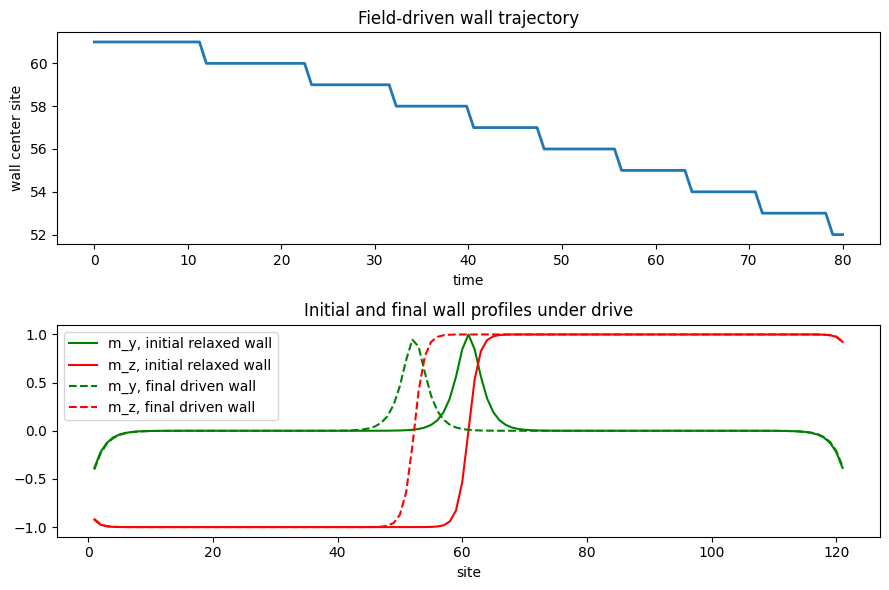

In [37]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=false)

ax[1].plot(sol_drive.t, centers_drive, lw=2)
ax[1].set_xlabel("time")
ax[1].set_ylabel("wall center site")
ax[1].set_title("Field-driven wall trajectory")

ax[2].plot(sites, s_eq[2, :], "g", label="m_y, initial relaxed wall")
ax[2].plot(sites, s_eq[3, :], "r", label="m_z, initial relaxed wall")
ax[2].plot(sites, s_drive_final[2, :], "g--", label="m_y, final driven wall")
ax[2].plot(sites, s_drive_final[3, :], "r--", label="m_z, final driven wall")
ax[2].set_xlabel("site")
ax[2].set_title("Initial and final wall profiles under drive")
ax[2].legend(loc="best")

plt.tight_layout()


## Notes

- This is a qualitative lattice-Landau-Lifshitz-Gilbert test, not a calibrated micromagnetic benchmark in physical units.
- If the drive is too large, the wall will tilt away from a purely Bloch texture during motion. Lower `B_drive[3]` to stay closer to the quasistatic regime.
- Changing the sign of `D_bulk[1]` flips the preferred Bloch chirality.
